# 6 - Hierarchical Clustering

## Imports

In [147]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
%reload_ext autoreload
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
from scipy.cluster.hierarchy import linkage, dendrogram

In [149]:
%reload_ext autoreload
import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa

## Test

In [151]:
def make_chord_test(pitches):
    result = []
    for pitch in pitches:
        result.append(m21.pitch.Pitch(pitch))

    return result

In [152]:
def get_chord_distance_semitones(chord1, chord2):
    distance = 0
    for note1 in chord1:
        for note2 in chord2:
            intvl = m21.interval.Interval(noteStart=note1, noteEnd=note2)
            semitones = intvl.semitones % 24
            distance += semitones 
    return distance

In [153]:
def get_chord_distance_linefifths(chord1, chord2):
    distance = 0
    for note1 in chord1:
        for note2 in chord2:
            note1tpc = pa.get_tpc(note1)
            note2tpc = pa.get_tpc(note2)
            distance += abs(note1tpc - note2tpc)
    return distance

In [154]:
def transpose_chord(chord):
    
    if not isinstance(chord, m21.chord.Chord):
        chord = m21.chord.Chord(chord)
        
    transposed_chords = []
    
    for semitones in range(1, 12):
        intvl = interval.Interval(semitones)
        transposed = chord.transpose(intvl)
        transposed_chords.append(transposed)
        
    return transposed_chords

In [155]:
### HOW TO HANDLE MIN_DISTANCE = 0 ????
def get_norm_distance(chord1, chord2, method="semitones"):
    if method not in ["semitones", "line of fifths"]:
        raise ValueError("method must be 'semitones' or 'line of fifths'")
        
    min_distance = float('inf')
    transposed_chords = transpose_chord(chord2)

    for chord in transposed_chords:

        if method == 'semitones':
            distance = get_chord_distance_semitones(chord1, chord)
        if method == 'line of fifths':
           distance = get_chord_distance_linefifths(chord1, chord) 
        
        if (distance < min_distance) and (min_distance != 0):
            min_distance = distance

    if method == 'semitones':
        result = get_chord_distance_semitones(chord1, chord2) / min_distance 
    if method == 'line of fifths':
        result = get_chord_distance_linefifths(chord1, chord2) / min_distance     

    return result

In [156]:
C = make_chord_test(['C4', 'E4', 'G4'])
Cm = make_chord_test(['C4', 'E4-', 'G4'])
G = make_chord_test(['G4', 'B4', 'D4'])
F = make_chord_test(['F4', 'A4', 'C4'])
Cdom7 = make_chord_test(['C4', 'E4', 'G4', 'B-4'])

In [157]:
chords = [(C, Cm),(C, G),(C, F),(G, F),(C, Cdom7)]

for chord1, chord2 in chords:
    chord1_name  = m21.chord.Chord(chord1).pitchedCommonName
    chord2_name  = m21.chord.Chord(chord2).pitchedCommonName
    print(f"{chord1_name} vs {chord2_name} semitone distance: " + str(get_chord_distance_semitones(chord1, chord2)))
    print(f"{chord1_name} vs {chord2_name} line of fifths distance: " + str(get_chord_distance_linefifths(chord1, chord2)))

C-major triad vs C-minor triad semitone distance: 93
C-major triad vs C-minor triad line of fifths distance: 23
C-major triad vs G-major triad semitone distance: 75
C-major triad vs G-major triad line of fifths distance: 19
C-major triad vs F-major triad semitone distance: 81
C-major triad vs F-major triad line of fifths distance: 19
G-major triad vs F-major triad semitone distance: 126
G-major triad vs F-major triad line of fifths distance: 24
C-major triad vs C-dominant seventh chord semitone distance: 91
C-major triad vs C-dominant seventh chord line of fifths distance: 27


## Test

In [159]:
metadata = g.load_metadata()

In [160]:
notes = g.load_notes(metadata.iloc[[0]])

In [161]:
def get_clustering_data(notes):

    min_tpc = notes['tpc'].min()
    max_tpc = notes['tpc'].max()
    vec_size = max_tpc - min_tpc + 1
    
    tpc_labels = [str(i) for i in range(min_tpc, max_tpc + 1)]
    # DETERMINE HOW TO SLICE SCORES 
    # Example: slicing by measure
    notes_per_measure = notes[['mc', 'tpc', 'note']].groupby('mc', as_index=False).agg(list)

    rows = []

    for _, row in notes_per_measure.iterrows():
        vec = np.zeros(vec_size)
        tpcs = row['tpc']
        tot_notes = len(tpcs)

        for tpc in tpcs:
            ind = tpc - min_tpc
            vec[ind] += 1

        vec = vec / tot_notes

        vec_dict = dict(zip(tpc_labels, vec))
        vec_dict['mc'] = row['mc']
        rows.append(vec_dict)

    return pd.DataFrame(rows)

notes_vectors = get_clustering_data(notes)

subset_cols = [col for col in notes_vectors.columns if col != 'mc']
notes_no_dups = notes_vectors.drop_duplicates(subset=subset_cols)
notes_no_dups

,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,mc
0,0.0,0.0,0.666667,0.0,0.000000,0.000000,0.0,0.000000,0.333333,0.0,0.0000,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.000000,0.0,0.000000,0.166667,0.0,0.666667,0.166667,0.0,0.0000,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.000000,0.0,0.000000,0.333333,0.0,0.666667,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.333333,0.0,0.000000,0.333333,0.0,0.333333,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,4
6,0.0,0.0,0.444444,0.0,0.000000,0.222222,0.0,0.222222,0.111111,0.0,0.0000,0.0,0.0,0.0,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.0,0.0,0.090909,0.0,0.090909,0.181818,0.0,0.545455,0.090909,0.0,0.0000,0.0,0.0,0.0,0.0,128
130,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,131
131,0.0,0.0,0.000000,0.0,0.000000,0.625000,0.0,0.062500,0.000000,0.0,0.3125,0.0,0.0,0.0,0.0,134
132,0.0,0.0,0.000000,0.0,0.000000,0.125000,0.0,0.875000,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,135


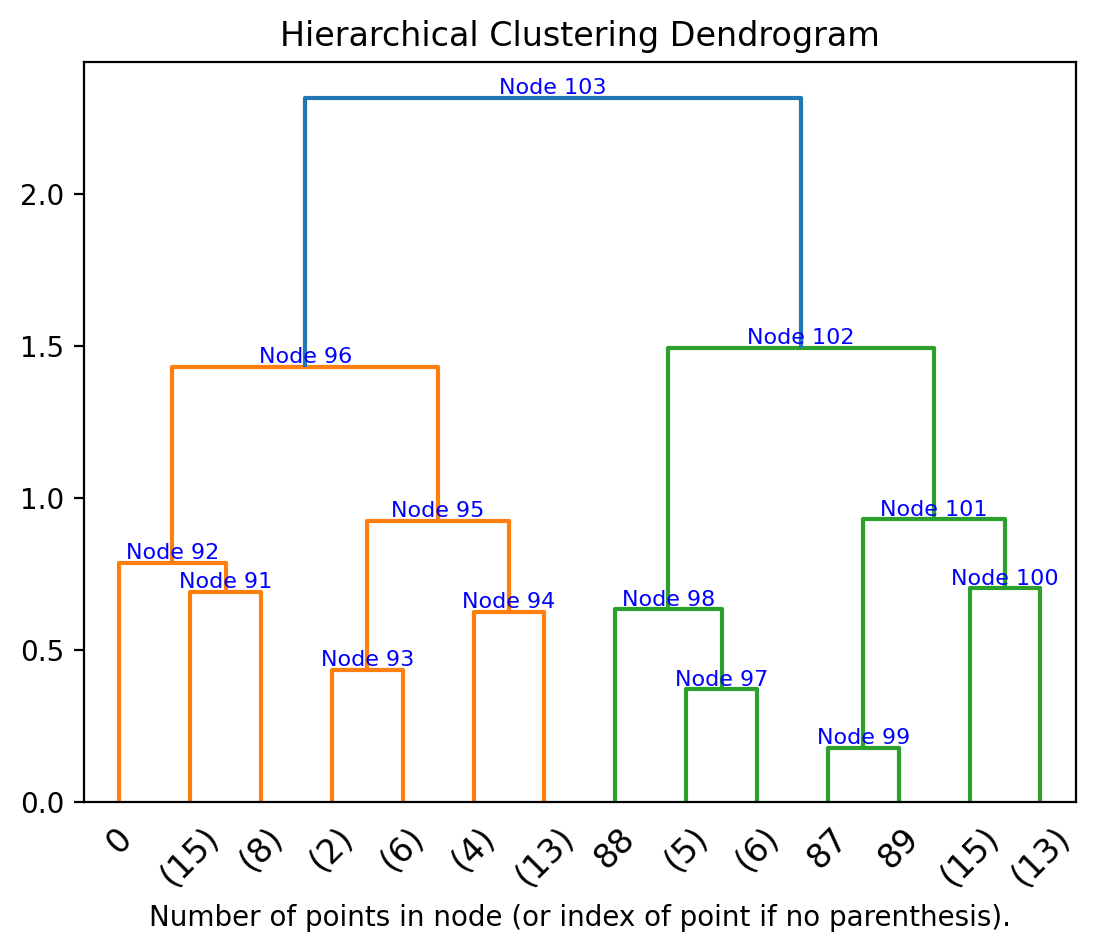

In [162]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendro = dendrogram(linkage_matrix, **kwargs)

    ax = plt.gca()
    icoord = np.array(dendro['icoord'])
    dcoord = np.array(dendro['dcoord'])
    
    # Label each internal node with its cluster id
    for i, d in enumerate(dcoord):
        x = 0.5 * (icoord[i, 1] + icoord[i, 2])
        y = d[1]
        cluster_id = n_samples + i  # new cluster ids start here
        ax.text(x, y, f"Node {cluster_id}", va='bottom', ha='center', fontsize=8, color='blue')

    return dendro


X = notes_no_dups.drop(columns=['mc']).to_numpy()

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
dendro = plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.xticks(rotation=45)
plt.show()

In [163]:
AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(X)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

In [231]:
clustering = AgglomerativeClustering(n_clusters=7).fit(X)
clustering

AgglomerativeClustering(n_clusters=7)

In [233]:
labels = clustering.labels_
labels 

array([6, 0, 0, 1, 1, 2, 2, 1, 0, 2, 1, 1, 2, 2, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 2, 2, 1, 0, 0, 3, 1, 0, 0, 1, 0, 0, 3, 1, 3, 3, 0, 1, 0,
       0, 1, 0, 0, 1, 2, 2, 1, 2, 2, 1, 0, 0, 3, 1, 0, 3, 3, 0, 3, 0, 0,
       3, 3, 3, 0, 3, 3, 0, 5, 3, 5, 5, 3, 5, 5, 3, 5, 5, 3, 5, 1, 0, 4,
       2, 4, 1])

In [14]:
notes_no_dups['cluster'] = labels

cluster_map = {
    cluster_id: group_df['mc'].tolist()
    for cluster_id, group_df in notes_no_dups.groupby('cluster')
}

NameError: name 'labels' is not defined

In [237]:
cluster_map

{0: [2,
  3,
  20,
  35,
  36,
  41,
  42,
  47,
  53,
  54,
  59,
  60,
  62,
  63,
  71,
  74,
  75,
  77,
  78,
  86,
  87,
  92,
  95,
  98,
  99,
  107,
  110,
  128],
 1: [4,
  7,
  19,
  28,
  31,
  34,
  37,
  40,
  43,
  46,
  49,
  52,
  58,
  61,
  67,
  73,
  76,
  79,
  82,
  85,
  91,
  127,
  136],
 2: [14, 15, 26, 32, 33, 50, 51, 80, 81, 83, 84, 134],
 3: [55,
  64,
  68,
  70,
  88,
  93,
  94,
  97,
  100,
  101,
  106,
  108,
  109,
  114,
  117,
  120,
  123],
 4: [131, 135],
 5: [113, 115, 116, 118, 119, 121, 122, 124],
 6: [1]}

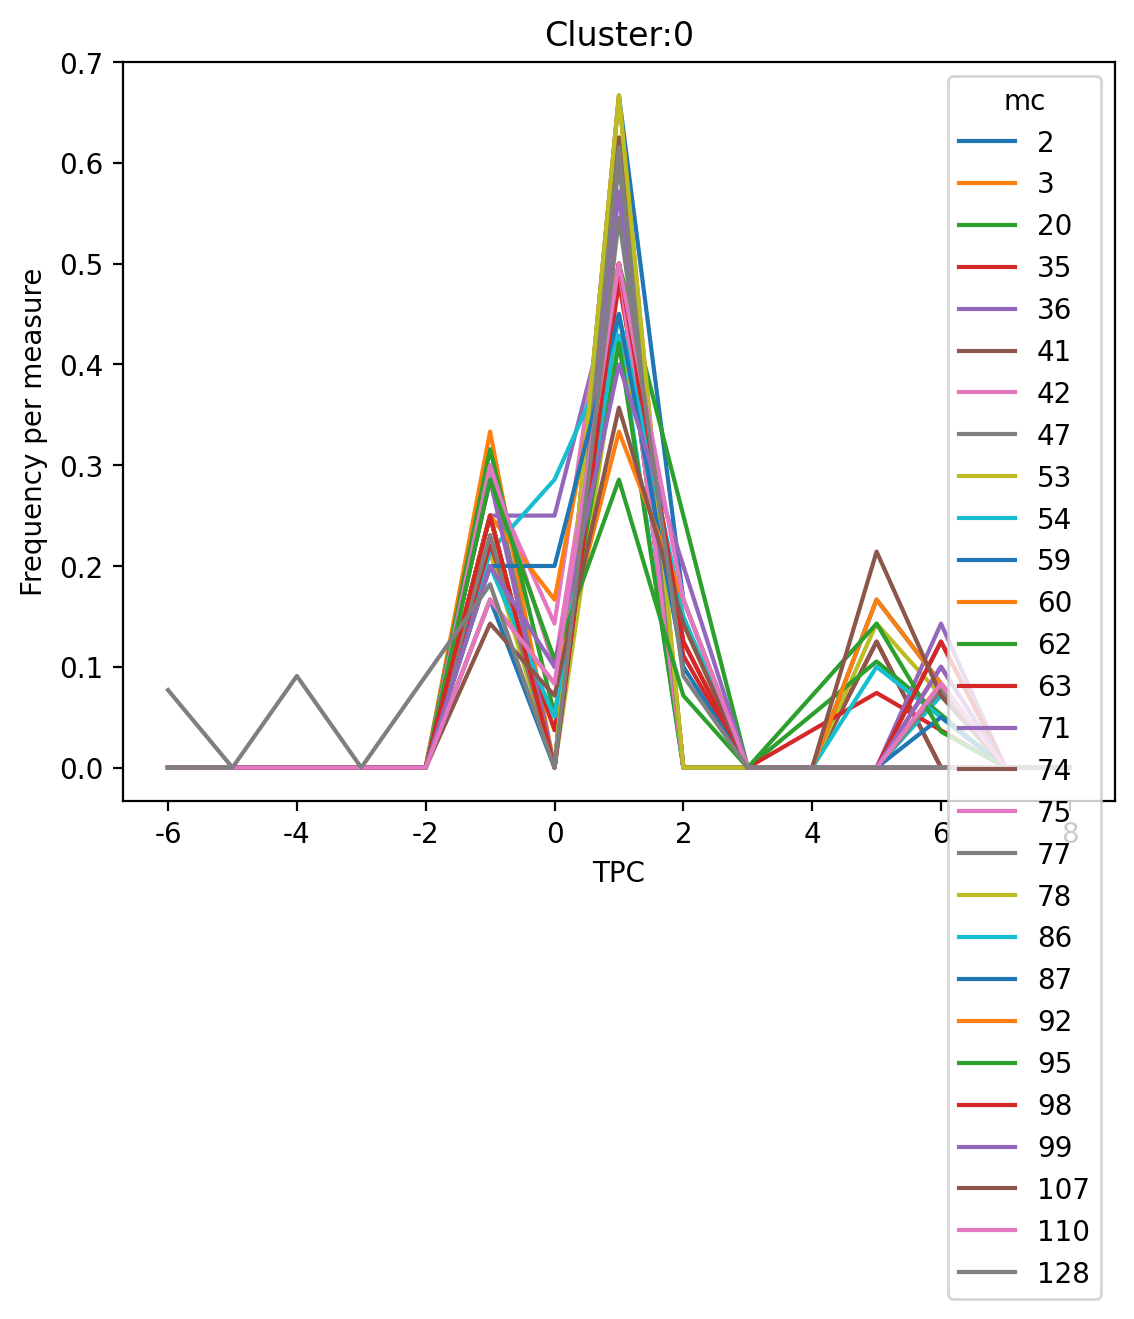

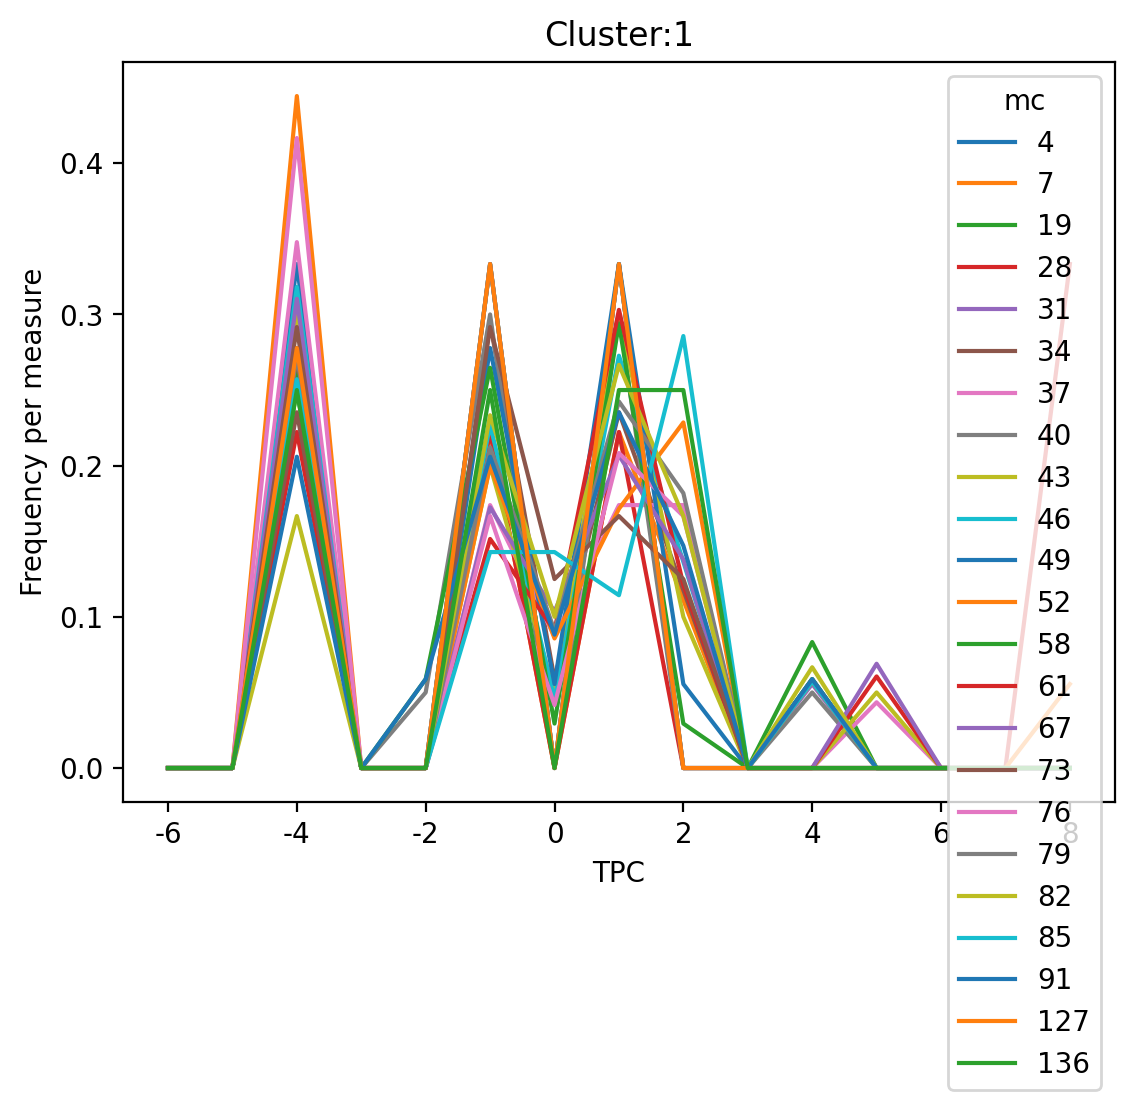

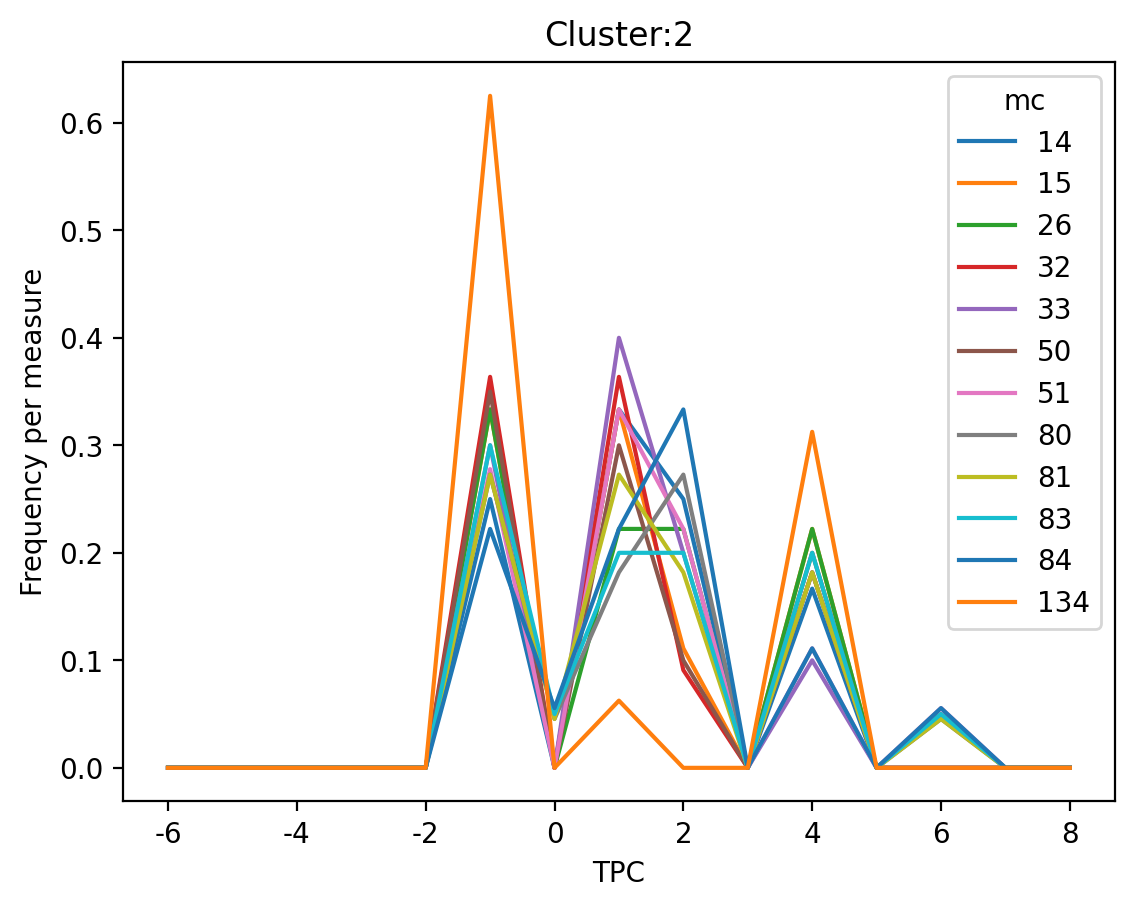

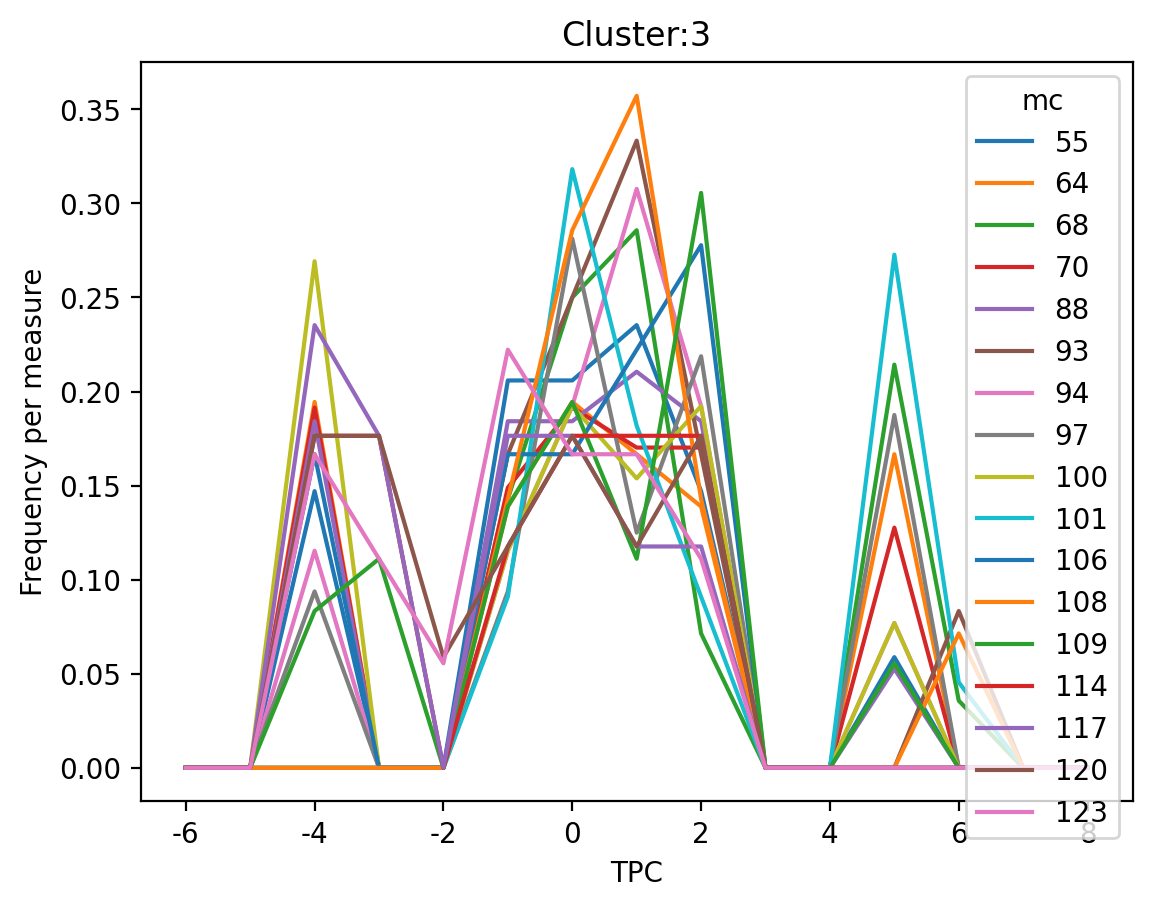

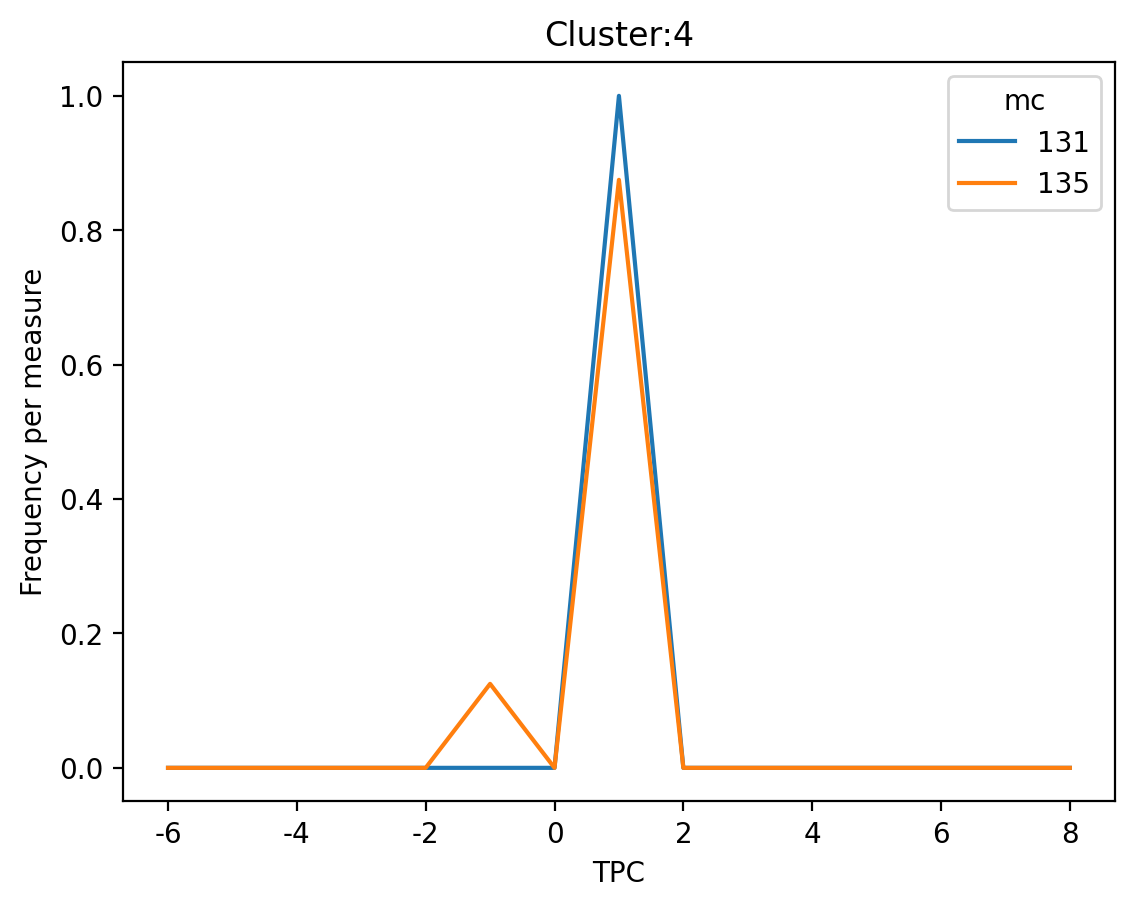

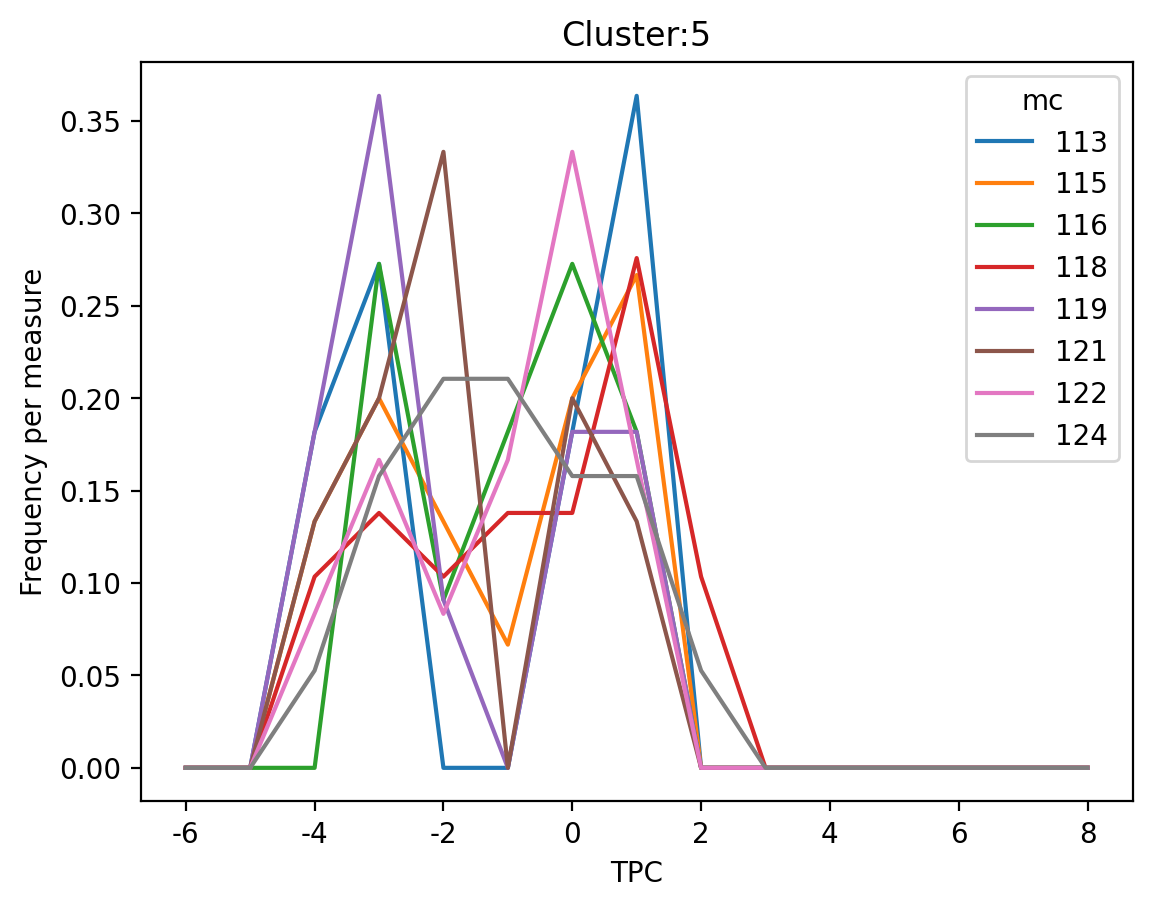

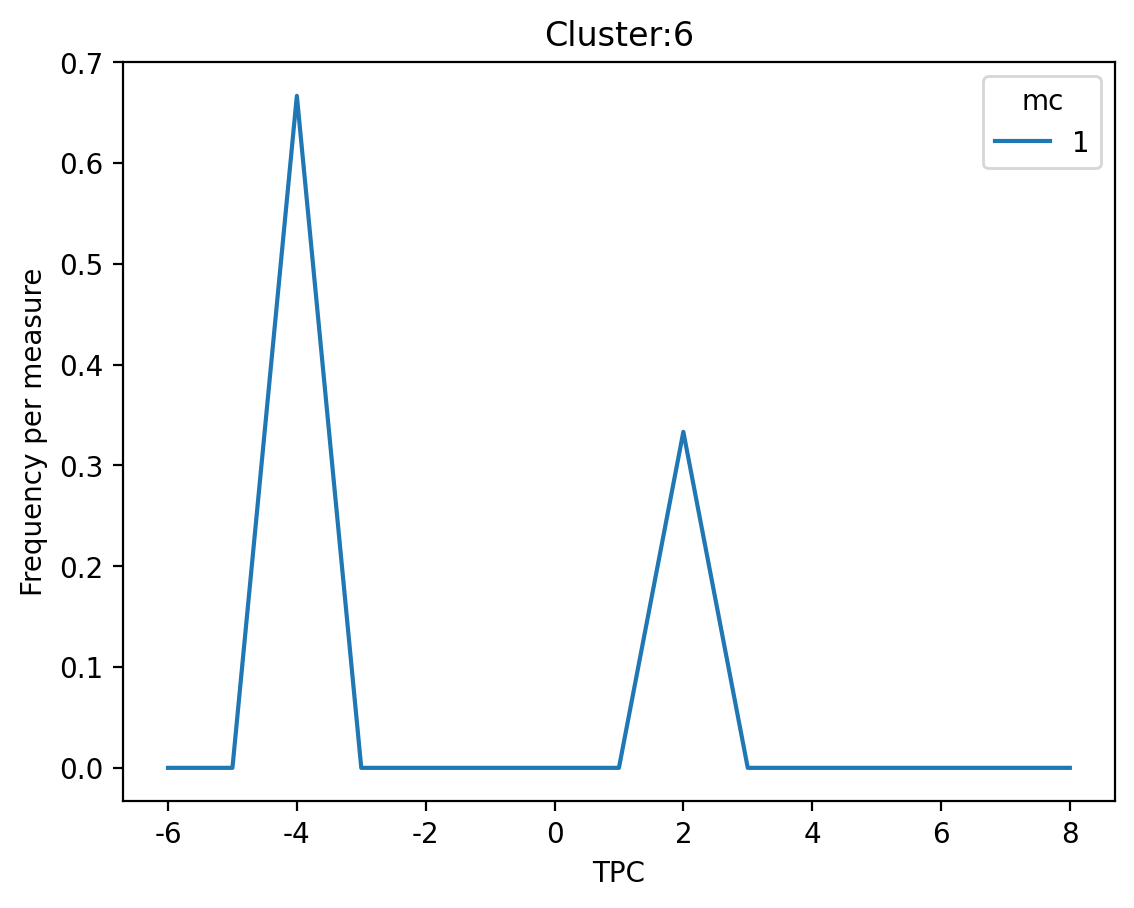

In [239]:
from scipy.spatial.distance import pdist
import numpy as np

cluster_intra_dists = {}

for key in cluster_map.keys():
    subset = notes_no_dups[notes_no_dups['cluster'] == key]
    X = subset.drop(columns=['cluster']).values  # matrix of points

    if len(X) > 1:
        # pairwise distances within the cluster
        dists = pdist(X, metric="euclidean")
        cluster_intra_dists[key] = dists.mean()
    else:
        cluster_intra_dists[key] = 0  # single point cluster has distance 0

print(cluster_intra_dists)
for key in cluster_map.keys():
    subset = notes_no_dups[notes_no_dups['cluster'] == key]
    plot_df = subset.drop(columns=['cluster']).set_index('mc')
    plot_df.T.plot()
    plt.title(f"Cluster:{key}")
    plt.xlabel('TPC')
    plt.ylabel('Frequency per measure')
    plt.show()

In [241]:
cluster_centers = {}

for key in cluster_map.keys():
    subset = notes_no_dups[notes_no_dups['cluster'] == key]
    plot_df = subset.drop(columns=['cluster']).set_index('mc')

    # cluster centroid = mean point across rows
    center = plot_df.mean(axis=0)   # vector of mean across all features

    cluster_centers[key] = center.values  # numpy array of coordinates

# If you want a DataFrame of all cluster centers
centers_df = pd.DataFrame(cluster_centers).T
centers_df.columns = plot_df.columns

In [243]:
centers_df

,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8
0,0.002747,0.0,0.003247,0.000000,0.003247,0.237947,0.061791,0.506770,0.071756,0.0,0.005753,0.048667,0.058076,0.0,0.000000
1,0.000000,0.0,0.284796,0.000000,0.007289,0.240957,0.051954,0.254443,0.110202,0.0,0.023753,0.009698,0.000000,0.0,0.016908
2,0.000000,0.0,0.000000,0.000000,0.000000,0.325063,0.016372,0.268761,0.182029,0.0,0.182607,0.000000,0.025168,0.0,0.000000
3,0.000000,0.0,0.129439,0.044214,0.006728,0.146192,0.211940,0.202295,0.169449,0.0,0.000000,0.075864,0.013878,0.0,0.000000
4,0.000000,0.0,0.000000,0.000000,0.000000,0.062500,0.000000,0.937500,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000
5,0.000000,0.0,0.108715,0.221448,0.130724,0.095451,0.208190,0.215962,0.019510,0.0,0.000000,0.000000,0.000000,0.0,0.000000
6,0.000000,0.0,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.0,0.000000,0.000000,0.000000,0.0,0.000000


In [ ]:
# Avg distance between clusters (compare for n=4,5,6, etc)
# Find average vector for each cluster -> this vector will outline chords
# Transpose to C
# Write outline for presentation